<a href="https://colab.research.google.com/github/jcmachicao/MachineLearningAvanzado_UC_2025/blob/main/cur_IAGenMM___vectorizacionMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import os
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [ ]:
ruta_archivo = "drive/My Drive/00 data/bike img/"
os.listdir(ruta_archivo)

['RKCOI6Q5LNAJZB5BTQTQJD4I74.jpeg',
 'download.jfif',
 'images.jfif',
 'download (1).jfif',
 'download (2).jfif',
 'download (3).jfif',
 'images (1).jfif',
 'images (2).jfif',
 'images (3).jfif',
 'images (4).jfif',
 'images (5).jfif',
 'images (6).jfif',
 'images (7).jfif',
 'images (8).jfif',
 'fotos_bicicletas.json',
 'reportes_reglamentos.json',
 'textos_multimodales.json']

In [ ]:
# CARGAR JSON
with open(ruta_archivo + "textos_multimodales.json", "r", encoding="utf-8") as f:
    data = json.load(f)

items = data["items"]
items[0]

{'id': 'img_01',
 'source': 'imagen',
 'type': 'descripcion_visual',
 'topic': 'accidente_interseccion',
 'title': 'Accidente urbano',
 'text': 'Ciclista atropellado en vía urbana con tráfico vehicular. Persona caída en la pista junto a bicicletas.',
 'keywords': ['accidente',
  'ciclista',
  'tráfico urbano',
  'colisión',
  'riesgo vial',
  'caída',
  'vehículos']}

* SENTENCE TRANSFORMERS
* TOPIC + KEYWORDS
* COLOR = TOPIC
* MARCADOR = TYPE

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

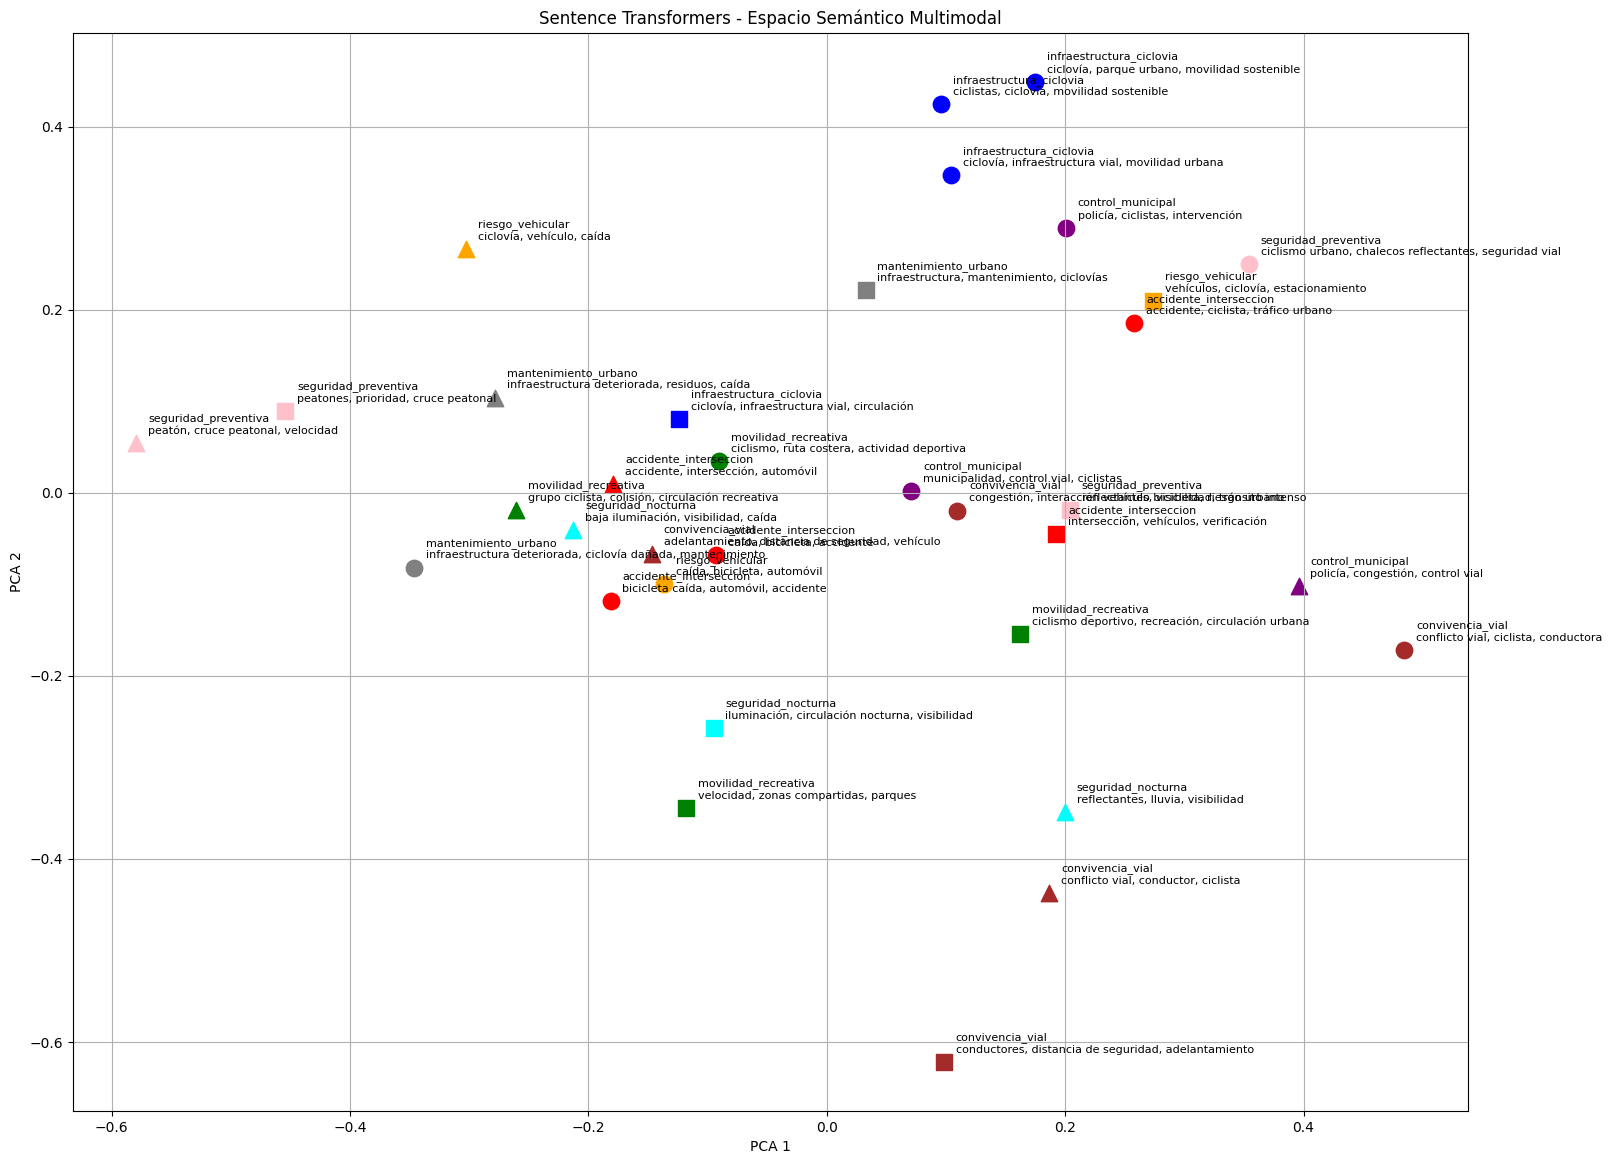

In [ ]:
# TEXTOS EMBEDDINGS PCA CLUSTERING COLORES POR TOPIC
texts = [item["text"] for item in items]

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(texts)
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(embeddings)

topic_colors = {
    "accidente_interseccion": "red",
    "infraestructura_ciclovia": "blue",
    "riesgo_vehicular": "orange",
    "movilidad_recreativa": "green",
    "control_municipal": "purple",
    "convivencia_vial": "brown",
    "seguridad_preventiva": "pink",
    "mantenimiento_urbano": "gray",
    "seguridad_nocturna": "cyan"
}

type_markers = {
    "descripcion_visual": "o",
    "reglamento": "s",
    "reporte": "^"
}

# PLOT
plt.figure(figsize=(18, 14))

for i, item in enumerate(items):

    topic = item["topic"]
    doc_type = item["type"]

    color = topic_colors.get(topic, "black")
    marker = type_markers.get(doc_type, "x")

    x = reduced[i][0]
    y = reduced[i][1]

    plt.scatter(
        x,
        y,
        c=color,
        marker=marker,
        s=140
    )

    # LABELS
    # topic en primera línea
    # keywords en segunda línea

    keywords = ", ".join(item["keywords"][:3])

    label = f"{topic}\n{keywords}"

    plt.text(
        x + 0.01,
        y + 0.01,
        label,
        fontsize=8
    )

plt.title("Sentence Transformers - Espacio Semántico Multimodal")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

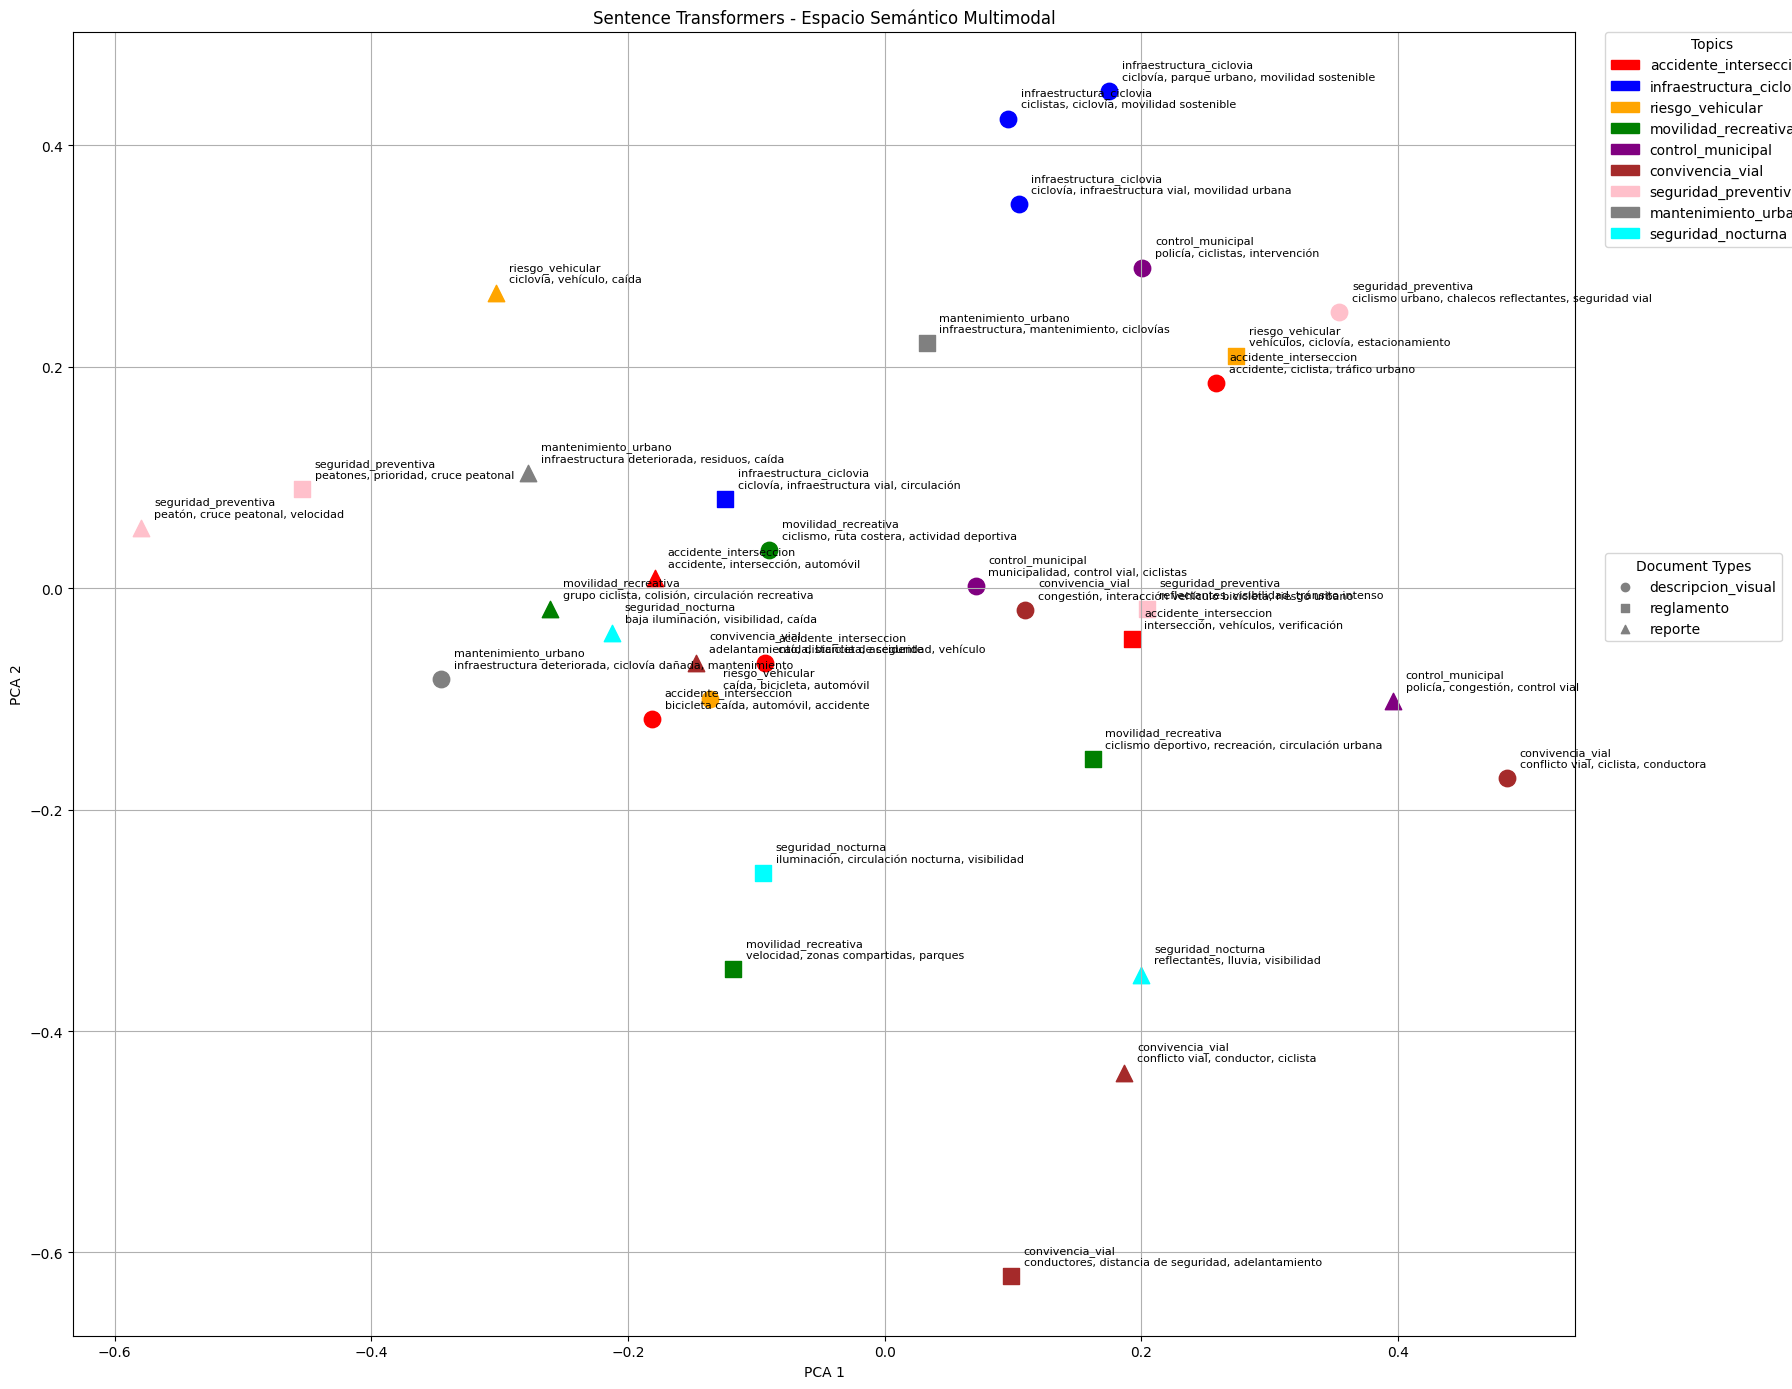

In [ ]:
import matplotlib.patches as mpatches

# PLOT (re-creating the plot to add legends)
plt.figure(figsize=(18, 14))

# Dictionaries to store handles for legends
topic_legend_handles = {}
type_legend_handles = {}

for i, item in enumerate(items):

    topic = item["topic"]
    doc_type = item["type"]

    color = topic_colors.get(topic, "black")
    marker = type_markers.get(doc_type, "x")

    x = reduced[i][0]
    y = reduced[i][1]

    # Plot the point
    plt.scatter(
        x,
        y,
        c=color,
        marker=marker,
        s=140,
        label=f"Topic: {topic}" if topic not in topic_legend_handles else "_nolegend_"
    )

    # Store dummy handles for topic colors for the legend
    if topic not in topic_legend_handles:
        topic_legend_handles[topic] = mpatches.Patch(color=color, label=topic)

    # Store dummy handles for type markers for the legend
    if doc_type not in type_legend_handles:
        # For markers, we plot a single invisible point to get the legend handle
        type_legend_handles[doc_type] = plt.scatter([], [], marker=marker, color='gray', label=doc_type)

    # LABELS
    # topic en primera línea
    # keywords en segunda línea

    keywords = ", ".join(item["keywords"][:3])

    label_text = f"{topic}\n{keywords}"

    plt.text(
        x + 0.01,
        y + 0.01,
        label_text,
        fontsize=8
    )

plt.title("Sentence Transformers - Espacio Semántico Multimodal")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)

# Create legend for topics (colors)
topic_legend = plt.legend(
    handles=list(topic_legend_handles.values()),
    title="Topics",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.
)

# Add the topic legend to the current axes
plt.gca().add_artist(topic_legend)

# Create legend for types (markers)
type_legend = plt.legend(
    handles=[handle for handle in type_legend_handles.values()],
    labels=[label for label in type_legend_handles.keys()],
    title="Document Types",
    bbox_to_anchor=(1.02, 0.6),
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout()
plt.show()